In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D
from tensorflow.keras import layers, optimizers, callbacks

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.applications import EfficientNetV2B2

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

import gradio as gr

In [27]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/jyotiyadav0000
/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage
/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage/TrashType_Image_Dataset
/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage/TrashType_Image_Dataset/metal
/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage/TrashType_Image_Dataset/glass
/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage/TrashType_Image_Dataset/paper
/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage/TrashType_Image_Dataset/trash
/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage/TrashType_Image_Dataset/cardboard
/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage/TrashType_Image_Dataset/plastic


In [28]:
dataset_dir = r"/kaggle/input/datasets/jyotiyadav0000/imbalanced-garbage/TrashType_Image_Dataset"
image_size = (224,224)
batch_size = 32
seed = 42

#traininag dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",  # different from "validation"
    seed=seed,
    shuffle=True,
    image_size=image_size,
    batch_size=batch_size
)


Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [29]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    shuffle = True,
    image_size=image_size,
    batch_size=batch_size
)
val_class= val_ds.class_names



Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [30]:
# Get the total number of batches in the validation dataset
val_batches = tf.data.experimental.cardinality(val_ds)

# Split the validation dataset into two equal parts:
# First half becomes the test dataset
test_ds = val_ds.take(val_batches // 2)

# Second half remains as the validation dataset
val_dat = val_ds.skip(val_batches // 2)

# Optimize test dataset by caching and prefetching to improve performance
test_ds_eval = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [31]:
print(train_ds.class_names)
print(val_class)
print(len(train_ds.class_names))


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
6


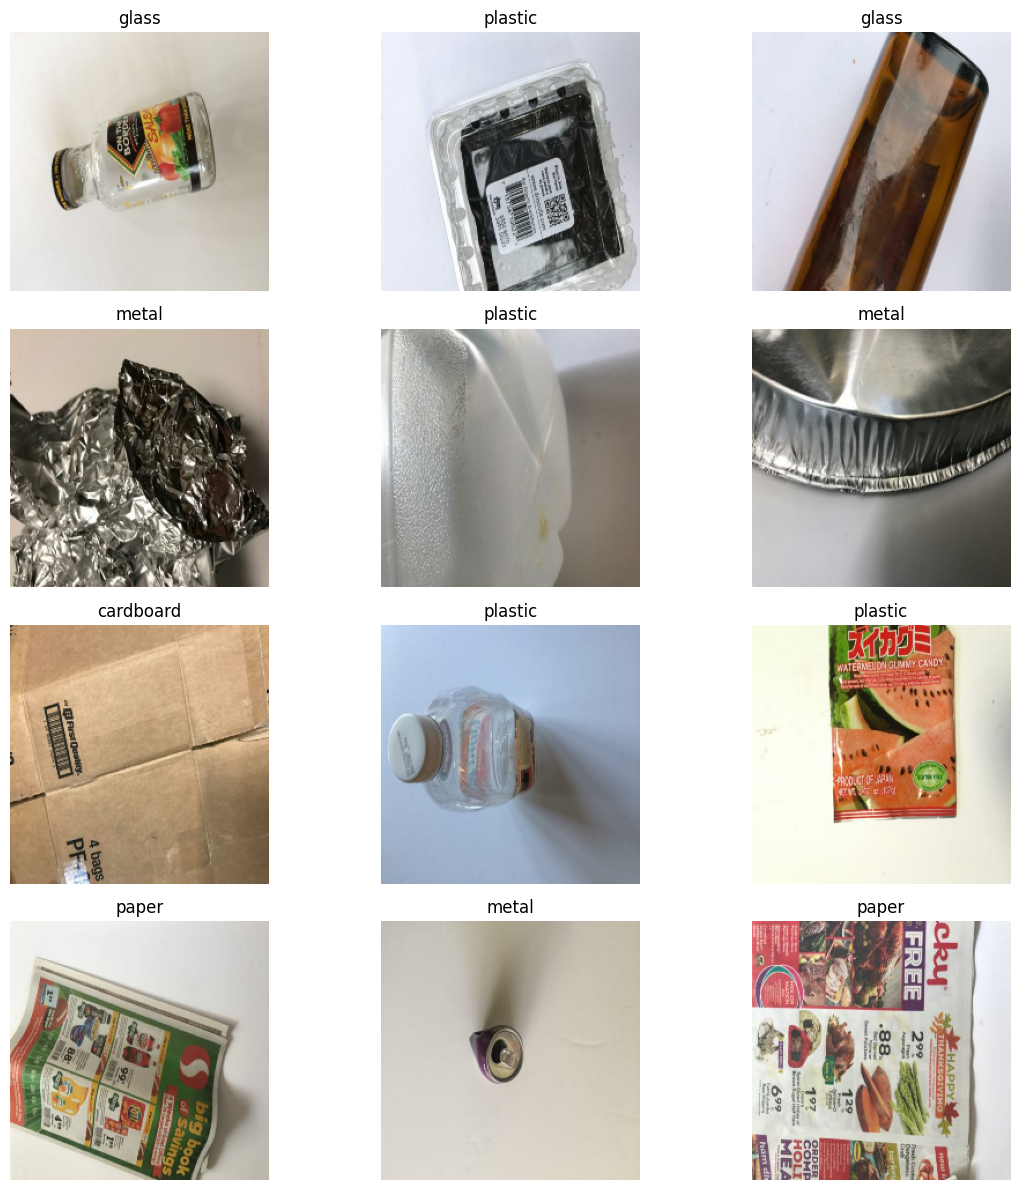

In [32]:
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):

        ax = plt.subplot(4, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
def count_distribution(dataset, class_names):
    total = 0
    counts = {name: 0 for name in class_names}

    for _, labels in dataset:
        for label in labels.numpy():
            class_name = class_names[label]
            counts[class_name] += 1
            total += 1

    if total == 0:
        print("⚠️ Dataset is empty. Cannot compute class distribution.")
        return counts  # Return raw zero counts (or empty if you prefer)

    for k in counts:
        counts[k] = round((counts[k] / total) * 100, 2)  # Convert to percentage

    return counts

In [34]:
# Function to plot class distribution
def simple_bar_plot(dist, title):
    plt.bar(dist.keys(), dist.values(), color='cornflowerblue')
    plt.title(title)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

In [35]:
class_names = train_ds.class_names

# Get class distributions
train_dist = count_distribution(train_ds, class_names)
val_dist = count_distribution(val_ds, class_names)
test_dist = count_distribution(test_ds, class_names)
overall_dist = {}
for k in class_names:
    overall_dist[k] = round((train_dist[k] + val_dist[k]) / 2, 2)

print(train_dist)
print(val_dist)
print(test_dist)
print(overall_dist)

{'cardboard': 16.52, 'glass': 19.73, 'metal': 15.92, 'paper': 23.29, 'plastic': 19.44, 'trash': 5.09}
{'cardboard': 13.66, 'glass': 20.2, 'metal': 17.43, 'paper': 24.36, 'plastic': 17.62, 'trash': 6.73}
{'cardboard': 14.06, 'glass': 17.58, 'metal': 16.8, 'paper': 25.0, 'plastic': 19.14, 'trash': 7.42}
{'cardboard': 15.09, 'glass': 19.96, 'metal': 16.68, 'paper': 23.82, 'plastic': 18.53, 'trash': 5.91}


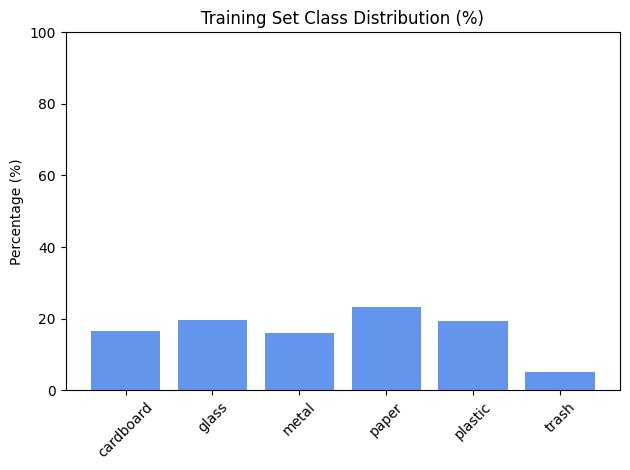

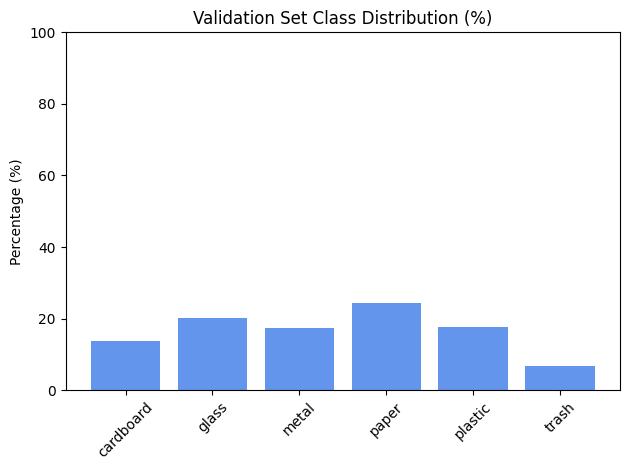

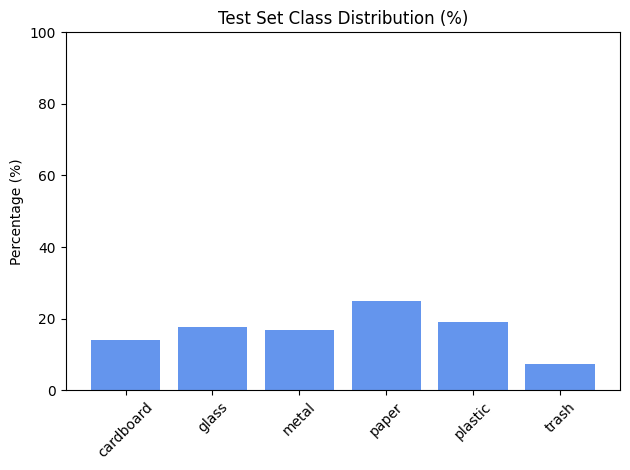

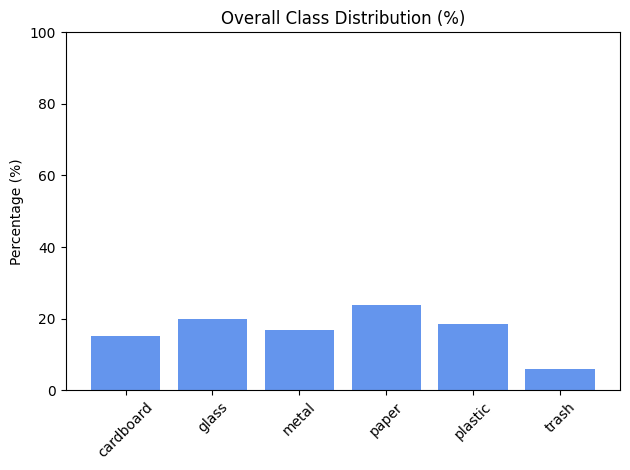

In [38]:
# Show visualizations
simple_bar_plot(train_dist, "Training Set Class Distribution (%)")
simple_bar_plot(val_dist, "Validation Set Class Distribution (%)")
simple_bar_plot(test_dist, "Test Set Class Distribution (%)")
simple_bar_plot(overall_dist, "Overall Class Distribution (%)")

In [39]:
# Count class occurrences and prepare label list
class_counts = {i: 0 for i in range(len(class_names))}
all_labels = []

for images, labels in train_ds:
    for label in labels.numpy():
        class_counts[label] += 1
        all_labels.append(label)

# Compute class weights (index aligned)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=all_labels
)

# Create dictionary mapping class index to weight
class_weights = {i: w for i, w in enumerate(class_weights_array)}

In [40]:
print("Class Weights:")
for i, weight in class_weights.items():
    print(f"{class_names[i]}: {weight:.2f}")

Class Weights:
cardboard: 1.01
glass: 0.84
metal: 1.05
paper: 0.72
plastic: 0.86
trash: 3.27


In [41]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
])

In [42]:
base_model = EfficientNetV2B2(
    include_top=False,
    input_shape=(224,224,3),
    include_preprocessing=True,
    weights="imagenet"
)

base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers: 349


In [49]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

In [50]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [57]:
# Number of epochs
epochs = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=[
        early,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9817 - loss: 0.0616
Epoch 1: val_accuracy improved from None to 0.92475, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.9822 - loss: 0.0653 - val_accuracy: 0.9248 - val_loss: 0.2194 - learning_rate: 4.0000e-06
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9758 - loss: 0.0613
Epoch 2: val_accuracy did not improve from 0.92475
64/64 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.9777 - loss: 0.0631 - val_accuracy: 0.9248 - val_loss: 0.2406 - learning_rate: 4.0000e-06
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9787 - loss: 0.0593
Epoch 3: val_accuracy did not improve from 0.92475
64/64 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.9832 - loss: 0.0583 - val_accuracy: 0.9248 - val_loss: 0.2132 - learning_rate: 4.0000e-06
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9775 - loss: 0.0

In [58]:
model.summary()
base_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b2 (Functional)  │ (None, 7, 7, 1408)     │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         8,454 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,727,114 (94.33 MB)

 Trainable params: 7,974,642 (30.42 MB)

 Non-trainable params: 803,186 (3.06 MB)

...

Model: "efficientnetv2-b2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      2,304 │ block1a_project_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         64 │ block1b_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 16)               │            │ block1a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b

 Total params: 8,769,374 (33.45 MB)

 Trainable params: 7,966,188 (30.39 MB)

 Non-trainable params: 803,186 (3.06 MB)

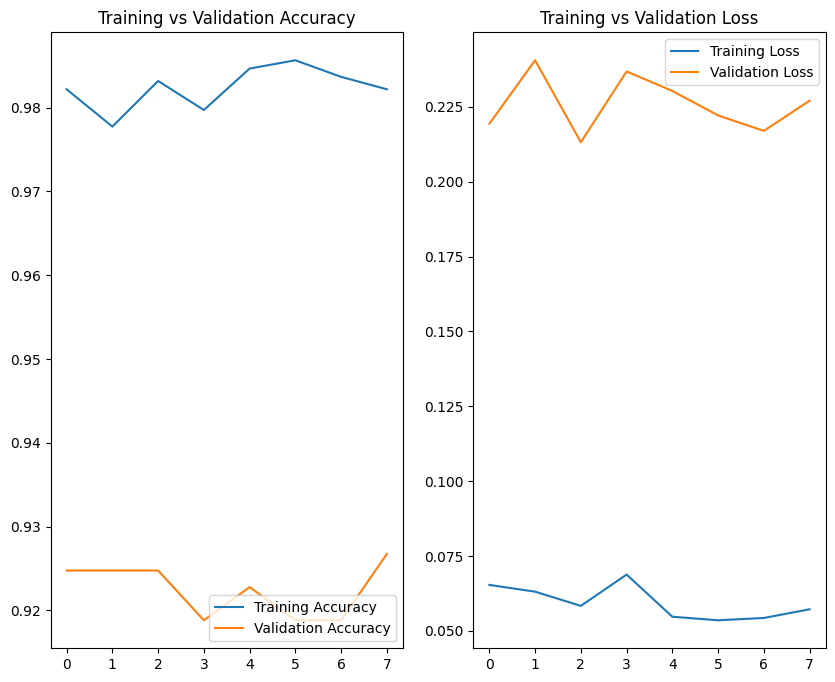

In [59]:

acc = history.history['accuracy']          
val_acc = history.history['val_accuracy']  
loss = history.history['loss']             
val_loss = history.history['val_loss']     

epochs_range = range(len(acc))            

plt.figure(figsize=(10,8))                

plt.subplot(1,2,1)                         
plt.plot(epochs_range, acc, label='Training Accuracy')      
plt.plot(epochs_range, val_acc, label='Validation Accuracy') 
plt.legend(loc='lower right')              
plt.title('Training vs Validation Accuracy') 

plt.subplot(1,2,2)                         
plt.plot(epochs_range, loss, label='Training Loss')        
plt.plot(epochs_range, val_loss, label='Validation Loss')   
plt.legend(loc='upper right')              
plt.title('Training vs Validation Loss')   

plt.show()                                 

In [60]:
loss, accuracy = model.evaluate(test_ds_eval)
print(f'Test accuracy is{accuracy:.4f}, Test loss is {loss:.4f}')

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9453 - loss: 0.1821
Test accuracy is0.9453, Test loss is 0.1821


In [61]:
    test_batches = list(test_ds_eval)

    # Extract true labels
    y_true = np.concatenate([y.numpy() for x, y in test_batches], axis=0)

    # Predict class probabilities
    y_pred_probs = model.predict(test_ds_eval)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Compute and display confusion matrix and classification report
    cm = confusion_matrix(y_true, y_pred)
    print("✅ Confusion Matrix:")
    print(cm)

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred))




8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
✅ Confusion Matrix:
[[28  0  0  5  0  0]
 [ 0 47  0  0  2  0]
 [ 0  0 44  0  0  1]
 [ 0  0  0 63  1  1]
 [ 0  1  0  0 42  2]
 [ 0  0  0  1  0 18]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        33
           1       0.98      0.96      0.97        49
           2       1.00      0.98      0.99        45
           3       0.91      0.97      0.94        65
           4       0.93      0.93      0.93        45
           5       0.82      0.95      0.88        19

    accuracy                           0.95       256
   macro avg       0.94      0.94      0.94       256
weighted avg       0.95      0.95      0.95       256



In [62]:
    # Additional Metrics
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")


Precision: 0.9487
Recall: 0.9453
F1 Score: 0.9456


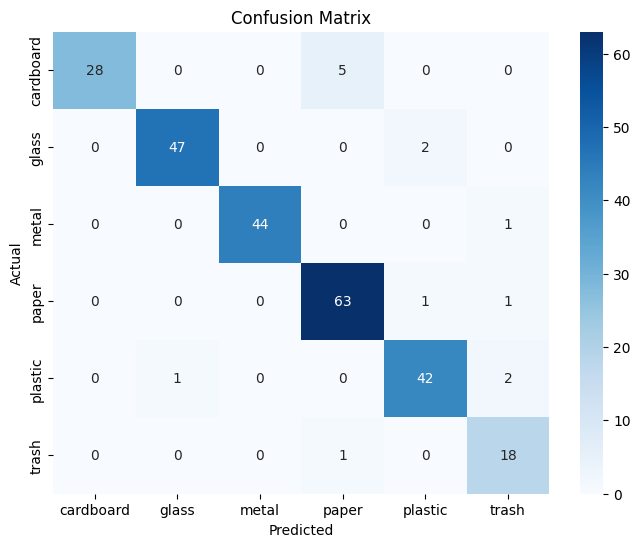

In [63]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [64]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_ds_eval:

    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(len(labels)):
        if labels[i] != pred_labels[i]:

            misclassified_images.append(images[i].numpy())
            misclassified_true.append(labels[i].numpy())
            misclassified_pred.append(pred_labels[i])

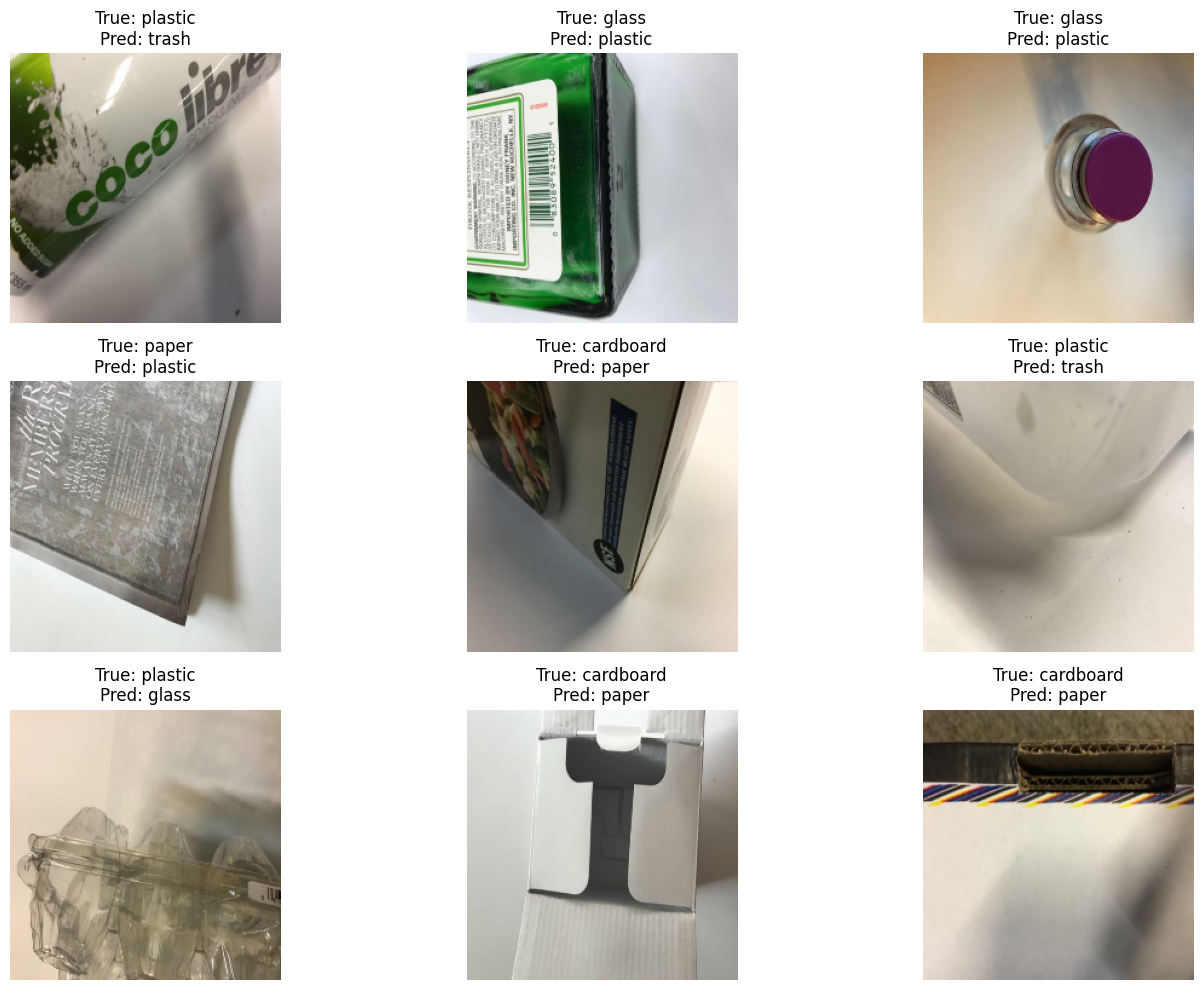

In [65]:
plt.figure(figsize=(15,10))

num_images = min(9, len(misclassified_images))

for i in range(num_images):

    plt.subplot(3,3,i+1)

    plt.imshow(misclassified_images[i].astype("uint8"))

    plt.title(
        f"True: {class_names[misclassified_true[i]]}\n"
        f"Pred: {class_names[misclassified_pred[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


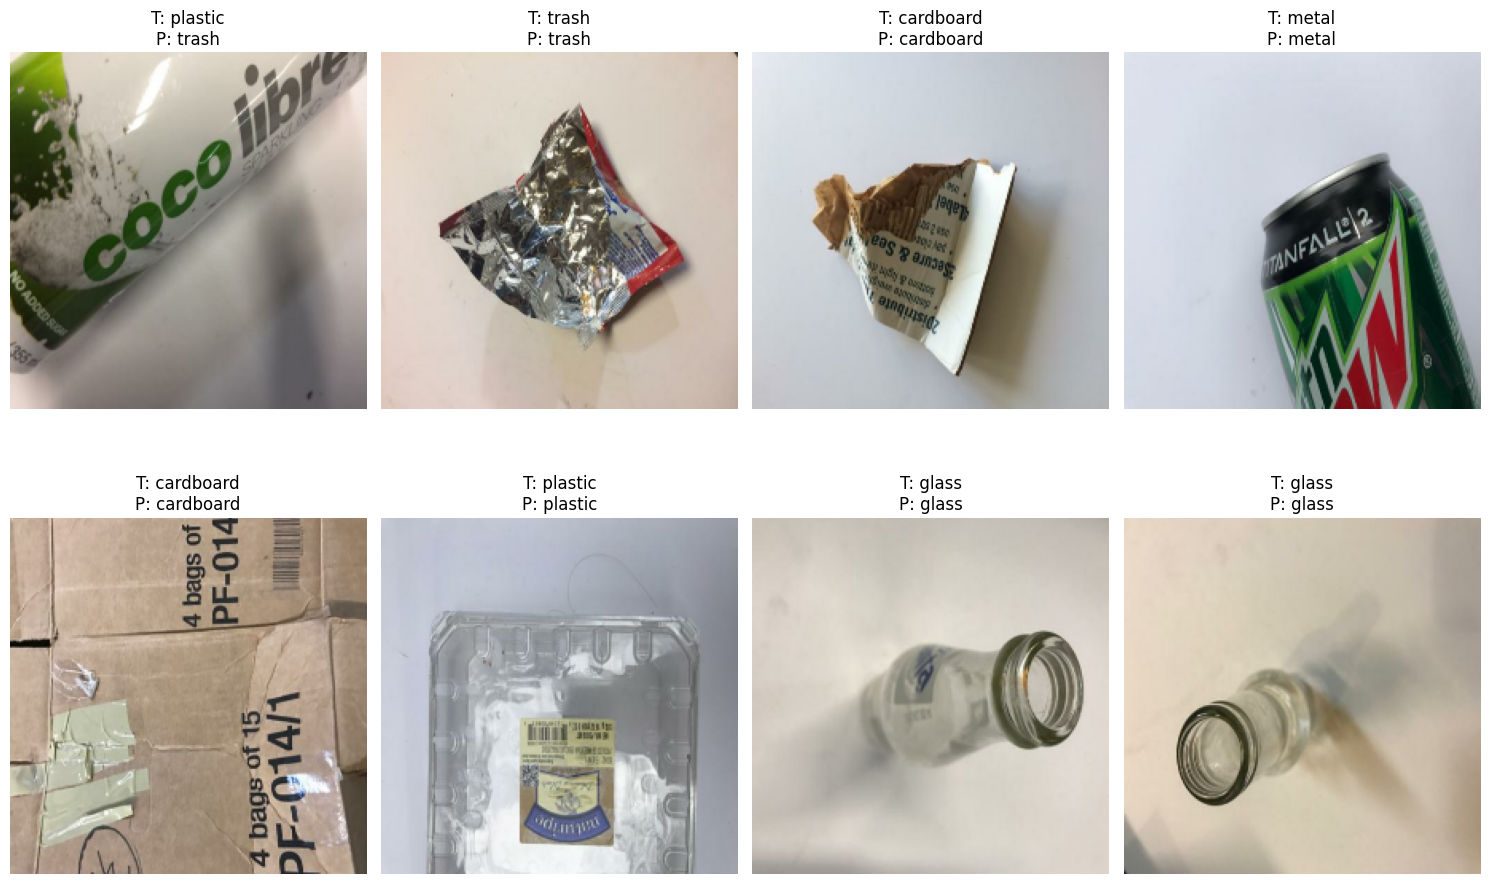

In [67]:
# Sample Predictions on Test Images
class_names = train_ds.class_names

for images, labels in test_ds_eval.take(1):

    predictions = model.predict(images)

    pred_labels = tf.argmax(predictions, axis=1)

    plt.figure(figsize=(15,10))

for i in range(8):
    plt.subplot(2,4,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))

    plt.title(
        f"T: {class_names[labels[i]]}\n"
        f"P: {class_names[pred_labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [80]:
# Save model in Keras format with architecture, weights, and training configuration
model.save('garbage_classifier.keras')

# Load Keras model
model = tf.keras.models.load_model('garbage_classifier.keras')

In [81]:
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

In [75]:
def classify_image(img):

    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)

    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_class_index = np.argmax(prediction)

    predicted_class_name = class_names[predicted_class_index]

    confidence = prediction[0][predicted_class_index]

    return f"Predicted: {predicted_class_name} (Confidence: {confidence:.2%})"

In [76]:
iface = gr.Interface(
    fn=classify_image,  # Function to classify image using the trained model
    inputs=gr.Image(type="pil"),  # Accepts input as a PIL image
    outputs="text"  # Outputs prediction as text
)

# Launch the interface
iface.launch()  # Start the Gradio interface for user interaction

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://10197ab377208ee104.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error